# MountainCar-v0 — Semi-Gradient SARSA with Tile Coding

In this notebook we train an agent to drive a car up a hill using reinforcement learning.  
The car is underpowered and must swing back and forth to build momentum.

We use **tile coding** to convert the car's position and velocity into features,  
and **semi-gradient SARSA** to learn which actions are best.

In [20]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym   


plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["image.cmap"] = "viridis"   # for heatmaps 

##  Tile Coder

The car's state is two continuous numbers: **position** and **velocity**.  
Neural networks or tables can't handle these directly, so we convert them into a binary feature vector using **tile coding**.

- The state space is divided into a grid of tiles
- Multiple overlapping grids (called *tilings*) are stacked on top of each other
- For any given state, exactly one tile per tiling is "active" (= 1), the rest are 0

This gives us a fixed-size feature vector that the learning algorithm can work with.

In [21]:
class TileCoder:
    """
    Tile coding for 2D continuous states (e.g. MountainCar position & velocity).

    - num_tilings: number of overlapping tilings (e.g. 8)
    - tiles_per_dim: [n_pos, n_vel] tiles per dimension per tiling (e.g. [8, 8])
    - state_bounds: [(pos_low, pos_high), (vel_low, vel_high)]
    """

    def __init__(self, num_tilings, tiles_per_dim, state_bounds):
        self.num_tilings = int(num_tilings)
        self.tiles_per_dim = np.asarray(tiles_per_dim, dtype=int)
        self.state_bounds = np.asarray(state_bounds, dtype=float)
        self.num_dims = len(tiles_per_dim)

        # 
        self.tile_widths = (self.state_bounds[:, 1] - self.state_bounds[:, 0]) / (self.tiles_per_dim - 1)

        # Number of tiles per tiling (flattened)
        self.tiles_per_tiling = int(np.prod(self.tiles_per_dim))

        # Total number of features
        self.num_features = self.num_tilings * self.tiles_per_tiling

        # Offsets for each tiling (asymmetric displacement)
        self.offsets = []
        for i in range(self.num_tilings):
            offset = (i / self.num_tilings) * self.tile_widths
            self.offsets.append(offset)

    def _tile_coords_for_tiling(self, state, offset):
        """Return integer tile coordinates for a single tiling."""
        coords = []
        for d in range(self.num_dims):
            low, high = self.state_bounds[d]
            s = np.clip(state[d], low, high)  # clip to bounds
            s_offset = s - low + offset[d]

            
            tile = int(np.floor(s_offset / self.tile_widths[d]))

            tile = min(tile, self.tiles_per_dim[d] - 1)  # clip index
            coords.append(tile)
        return coords

    def get_active_tiles(self, state):
        """
        Return indices of active tiles (one per tiling).
        These indices are in [0, num_features).
        """
        state = np.asarray(state, dtype=float)
        active = []

        for tiling_idx, offset in enumerate(self.offsets):
            coords = self._tile_coords_for_tiling(state, offset)

            # Convert multi-dim coords to flat tile index within this tiling
            tile_index = 0
            multiplier = 1
            for d in reversed(range(self.num_dims)):
                tile_index += coords[d] * multiplier
                multiplier *= self.tiles_per_dim[d]

            # Global feature index = tiling_offset + tile_index
            feature_index = tiling_idx * self.tiles_per_tiling + tile_index
            active.append(feature_index)

        return np.asarray(active, dtype=int)

    def get_feature_vector(self, state):
        """
        Dense binary feature vector (NumPy array) with num_tilings active features.
        This is REQUIRED for np.dot implementation.
        """
        features = np.zeros(self.num_features, dtype=float)
        active = self.get_active_tiles(state)
        features[active] = 1.0
        return features

## Sanity Check

Quick test to make sure the tile coder is working correctly.  
For any state, we expect exactly **8 active tiles** (one per tiling).

In [22]:
# Sanity check: MountainCar bounds and features
state_bounds = [(-1.2, 0.6), (-0.07, 0.07)]  # (position, velocity)
tile_coder = TileCoder(num_tilings=8, tiles_per_dim=[8, 8], state_bounds=state_bounds)

test_state = np.array([0.0, 0.0])
features = tile_coder.get_feature_vector(test_state)

print("Num features:", tile_coder.num_features)
print("Active features:", np.sum(features))  # should be = num_tilings
print("Active indices:", np.nonzero(features)[0])

# Check Q computation shape
weights = np.zeros((3, tile_coder.num_features))  # 3 actions in MountainCar
Q = np.dot(weights[0], features)

print("Q-value shape check:", Q)

Num features: 512
Active features: 8.0
Active indices: [ 35  99 163 235 300 364 428 492]
Q-value shape check: 0.0


##  Semi-Gradient SARSA Algorithm

This is the main learning algorithm. The agent plays many episodes and slowly improves.

**How it works:**
1. The agent is in a state → picks an action (random sometimes, best guess other times)
2. It takes the action → gets a reward and lands in a new state
3. It updates its weights based on how wrong its prediction was (the *TD error*)
4. Repeat until the car reaches the goal or runs out of steps

The **epsilon-greedy** strategy means the agent explores randomly with probability ε,  
and exploits its best known action the rest of the time.

In [23]:
def semi_gradient_sarsa_mountaincar(
    env,
    tile_coder,
    num_episodes=500,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=0.1,
    epsilon_min=0.01,
    epsilon_decay=1.0,
    max_steps_per_episode=1000,
    seed=0,
):
    """
    Semi-gradient SARSA with tile coding for MountainCar-v0.

    Returns:
        weights: (n_actions, n_features)
        episode_lengths: steps per episode
    """

    np.random.seed(seed)

    n_actions = env.action_space.n
    n_features = tile_coder.num_features

    weights = np.zeros((n_actions, n_features), dtype=float)

    def q_value(state, action):
        active = tile_coder.get_feature_vector(state).nonzero()[0]
        return np.sum(weights[action, active])

    def q_values(state):
        active = tile_coder.get_feature_vector(state).nonzero()[0]
        return np.array([np.sum(weights[a, active]) for a in range(n_actions)])

    def epsilon_greedy(state, epsilon):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        return int(np.argmax(q_values(state)))

    episode_lengths = []
    epsilon = epsilon_start

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)

        active = tile_coder.get_feature_vector(state).nonzero()[0]
        action = epsilon_greedy(state, epsilon)

        steps = 0
        done = False

        while not done and steps < max_steps_per_episode:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1

            next_active = tile_coder.get_feature_vector(next_state).nonzero()[0]

            # Q(s,a)
            Q = np.sum(weights[action, active])

            if not done:
                next_action = epsilon_greedy(next_state, epsilon)
                Q_next = np.sum(weights[next_action, next_active])
                target = reward + gamma * Q_next
            else:
                target = reward

            # ✅ REQUIRED SEMI-GRADIENT UPDATE
            weights[action, active] += alpha * (target - Q)

            state = next_state
            active = next_active
            action = epsilon_greedy(next_state, epsilon) if not done else action

        episode_lengths.append(steps)

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1:4d}, avg steps (last 50): {np.mean(episode_lengths[-50:]):.1f}, epsilon={epsilon:.3f}")

    return weights, np.array(episode_lengths)

## Training — Baseline Configuration (8×8 tiles, 8 tilings)

We train the agent for 500 episodes using the default tile coding setup.  
The plot shows how many steps the agent needed per episode — **lower = better**.  
Early on the agent struggles, but it should improve over time.

Episode   50, avg steps (last 50): 200.0, epsilon=0.100
Episode  100, avg steps (last 50): 199.9, epsilon=0.100
Episode  150, avg steps (last 50): 192.5, epsilon=0.100
Episode  200, avg steps (last 50): 176.1, epsilon=0.100
Episode  250, avg steps (last 50): 169.1, epsilon=0.100
Episode  300, avg steps (last 50): 151.5, epsilon=0.100
Episode  350, avg steps (last 50): 151.3, epsilon=0.100
Episode  400, avg steps (last 50): 142.9, epsilon=0.100
Episode  450, avg steps (last 50): 146.9, epsilon=0.100
Episode  500, avg steps (last 50): 140.9, epsilon=0.100


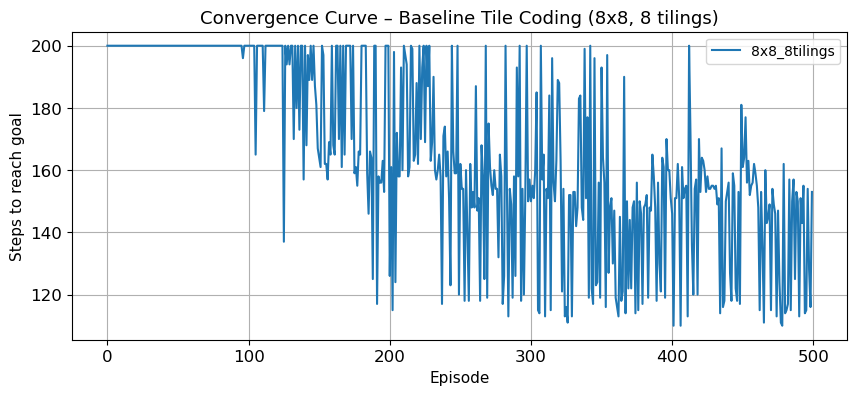

In [ ]:
env = gym.make("MountainCar-v0")

state_bounds = [(-1.2, 0.6), (-0.07, 0.07)]

# =========================
# FEATURE CONFIGURATIONS
# =========================
configs = {
    "8x8_8tilings": {"num_tilings": 8, "tiles_per_dim": [8, 8]},
    #"16x16_8tilings": {"num_tilings": 8, "tiles_per_dim": [16, 16]},
    #"8x8_16tilings": {"num_tilings": 16, "tiles_per_dim": [8, 8]},
}

results = {}

num_episodes = 500
gamma = 1.0
epsilon_start = 0.1
epsilon_min = 0.01
epsilon_decay = 1.0

# =========================
# RUN  CONFIG
# =========================
for name, cfg in configs.items():

    tile_coder = TileCoder(
        num_tilings=cfg["num_tilings"],
        tiles_per_dim=cfg["tiles_per_dim"],
        state_bounds=state_bounds,
    )

    alpha = 0.1 / tile_coder.num_tilings  # required scaling

    weights, episode_lengths = semi_gradient_sarsa_mountaincar(
        env,
        tile_coder,
        num_episodes=num_episodes,
        alpha=alpha,
        gamma=gamma,
        epsilon_start=epsilon_start,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay,
        max_steps_per_episode=1000,
        seed=42,
    )

    results[name] = episode_lengths

    plt.plot(episode_lengths, label=name)

# =========================
# PLOT 
# =========================
plt.xlabel("Episode")
plt.ylabel("Steps to reach goal")
plt.title("Convergence Curve – Baseline Tile Coding (8x8, 8 tilings)")
plt.legend()
plt.grid(True)
plt.show()

##  Comparing Different Tile Configurations

We test three different tile coding setups to see how resolution and number of tilings affect learning:

| Config | Tilings | Grid | Total Features |
|---|---|---|---|
| Small | 4 | 4×4 | 64 |
| Medium | 8 | 8×8 | 512 |
| Large | 16 | 8×8 | 1024 |

More tilings = smoother value estimates but slower per step.  
Larger grids = finer resolution but more memory.


Running config: 4 tilings, 4x4
Episode   50, avg steps (last 50): 196.4, epsilon=0.100
Episode  100, avg steps (last 50): 184.3, epsilon=0.100
Episode  150, avg steps (last 50): 175.3, epsilon=0.100
Episode  200, avg steps (last 50): 155.8, epsilon=0.100
Episode  250, avg steps (last 50): 163.7, epsilon=0.100
Episode  300, avg steps (last 50): 166.0, epsilon=0.100
Episode  350, avg steps (last 50): 173.5, epsilon=0.100
Episode  400, avg steps (last 50): 178.6, epsilon=0.100

Running config: 8 tilings, 8x8
Episode   50, avg steps (last 50): 200.0, epsilon=0.100
Episode  100, avg steps (last 50): 200.0, epsilon=0.100
Episode  150, avg steps (last 50): 190.1, epsilon=0.100
Episode  200, avg steps (last 50): 187.7, epsilon=0.100
Episode  250, avg steps (last 50): 161.7, epsilon=0.100
Episode  300, avg steps (last 50): 166.0, epsilon=0.100
Episode  350, avg steps (last 50): 149.7, epsilon=0.100
Episode  400, avg steps (last 50): 150.6, epsilon=0.100

Running config: 16 tilings, 8x8
Episode

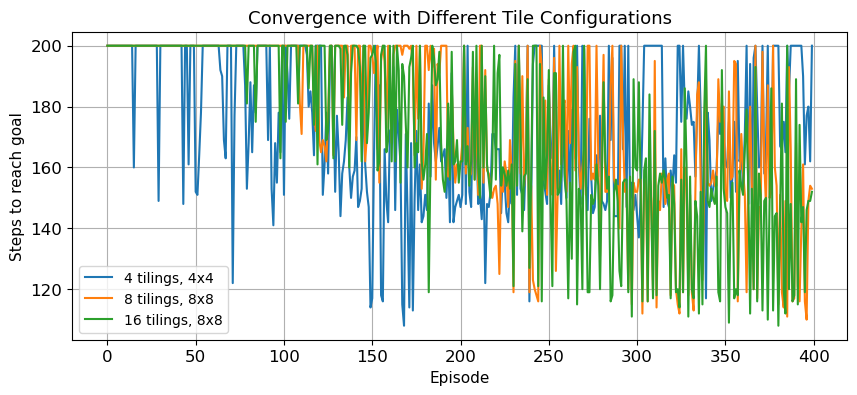

In [25]:
def run_config(env, num_tilings, tiles_per_dim, label, num_episodes=500, seed=0):
    tile_coder = TileCoder(
        num_tilings=num_tilings,
        tiles_per_dim=tiles_per_dim,
        state_bounds=state_bounds
    )

    alpha = 0.1 / num_tilings

    weights, lengths = semi_gradient_sarsa_mountaincar(
        env,
        tile_coder,
        num_episodes=num_episodes,
        alpha=alpha,
        gamma=1.0,
        epsilon_start=0.1,
        epsilon_min=0.01,
        epsilon_decay=1.0,
        max_steps_per_episode=1000,
        seed=seed,
    )

    return tile_coder, weights, lengths, label


# =========================
# EXPERIMENT SETUP
# =========================
env_comp = gym.make("MountainCar-v0")

configs = [
    (4,  [4, 4],  "4 tilings, 4x4"),
    (8,  [8, 8],  "8 tilings, 8x8"),
    (16, [8, 8],  "16 tilings, 8x8"),
]

results = []

# =========================
# RUN ALL CONFIGS
# =========================
for num_tilings, tiles_per_dim, label in configs:
    print("\nRunning config:", label)

    tile_coder_cfg, w_cfg, lengths_cfg, label_cfg = run_config(
        env_comp,
        num_tilings,
        tiles_per_dim,
        label,
        num_episodes=400,
        seed=0
    )

    results.append((tile_coder_cfg, w_cfg, lengths_cfg, label_cfg))

# =========================
# PLOT CONVERGENCE
# =========================
plt.figure()

for tile_coder_cfg, w_cfg, lengths_cfg, label_cfg in results:
    plt.plot(lengths_cfg, label=label_cfg)

plt.xlabel("Episode")
plt.ylabel("Steps to reach goal")
plt.title("Convergence with Different Tile Configurations")
plt.legend()
plt.grid(True)
plt.show()


Running config: 4 tilings, 4x4
Episode   50, avg steps (last 50): 198.1, epsilon=0.100
Episode  100, avg steps (last 50): 173.1, epsilon=0.100
Episode  150, avg steps (last 50): 171.8, epsilon=0.100
Episode  200, avg steps (last 50): 178.0, epsilon=0.100
Episode  250, avg steps (last 50): 174.3, epsilon=0.100
Episode  300, avg steps (last 50): 170.8, epsilon=0.100
Episode  350, avg steps (last 50): 171.8, epsilon=0.100
Episode  400, avg steps (last 50): 176.2, epsilon=0.100

Running config: 8 tilings, 8x8
Episode   50, avg steps (last 50): 200.0, epsilon=0.100
Episode  100, avg steps (last 50): 200.0, epsilon=0.100
Episode  150, avg steps (last 50): 192.5, epsilon=0.100
Episode  200, avg steps (last 50): 175.1, epsilon=0.100
Episode  250, avg steps (last 50): 162.4, epsilon=0.100
Episode  300, avg steps (last 50): 168.6, epsilon=0.100
Episode  350, avg steps (last 50): 155.6, epsilon=0.100
Episode  400, avg steps (last 50): 133.6, epsilon=0.100

Running config: 16 tilings, 8x8
Episode

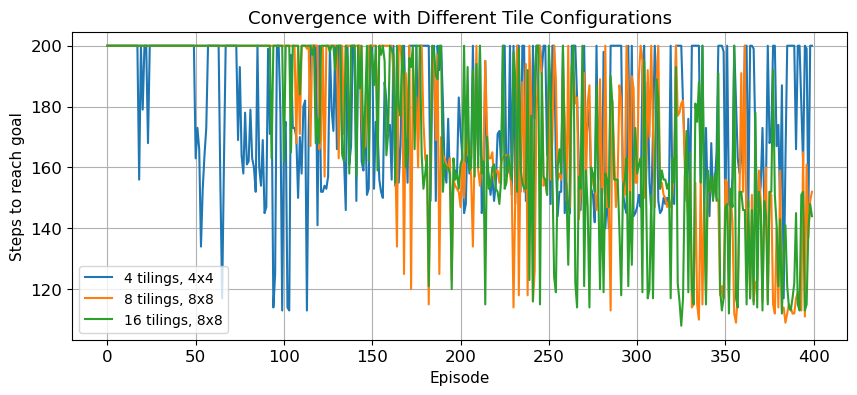

In [26]:
def run_config(env, num_tilings, tiles_per_dim, label, num_episodes=500, seed=0):
    tile_coder = TileCoder(
        num_tilings=num_tilings,
        tiles_per_dim=tiles_per_dim,
        state_bounds=state_bounds
    )

    
    alpha = 0.1 / num_tilings

    weights, lengths = semi_gradient_sarsa_mountaincar(
        env,
        tile_coder,
        num_episodes=num_episodes,
        alpha=alpha,
        gamma=1.0,
        epsilon_start=0.1,
        epsilon_min=0.01,
        epsilon_decay=1.0,
        max_steps_per_episode=1000,
        seed=seed,
    )

    return tile_coder, weights, lengths, label


# =========================
# ENVIRONMENT
# =========================
env_comp = gym.make("MountainCar-v0")

# =========================
# CONFIGURATIONS
# =========================
configs = [
    (4,  [4, 4],  "4 tilings, 4x4"),
    (8,  [8, 8],  "8 tilings, 8x8"),
    (16, [8, 8],  "16 tilings, 8x8"),
]

results = []

# =========================
# RUN EXPERIMENTS
# =========================
for num_tilings, tiles_per_dim, label in configs:
    print("\nRunning config:", label)

    tile_coder_cfg, w_cfg, lengths_cfg, label_cfg = run_config(
        env_comp,
        num_tilings,
        tiles_per_dim,
        label,
        num_episodes=400,
        seed=0
    )

    results.append((tile_coder_cfg, w_cfg, lengths_cfg, label_cfg))

# =========================
# PLOT CONVERGENCE
# =========================
plt.figure()

for tile_coder_cfg, w_cfg, lengths_cfg, label_cfg in results:
    plt.plot(lengths_cfg, label=label_cfg)

plt.xlabel("Episode")
plt.ylabel("Steps to reach goal")
plt.title("Convergence with Different Tile Configurations")
plt.legend()
plt.grid(True)
plt.show()

##  Value Function Heatmap

This heatmap shows how "good" each state (position, velocity) is according to the trained agent.  
Brighter (yellow) = closer to reaching the goal.  
The red dashed line marks the goal position (x = 0.5).

V min: -102.0583, V max: 0.7530, spread: 102.8113


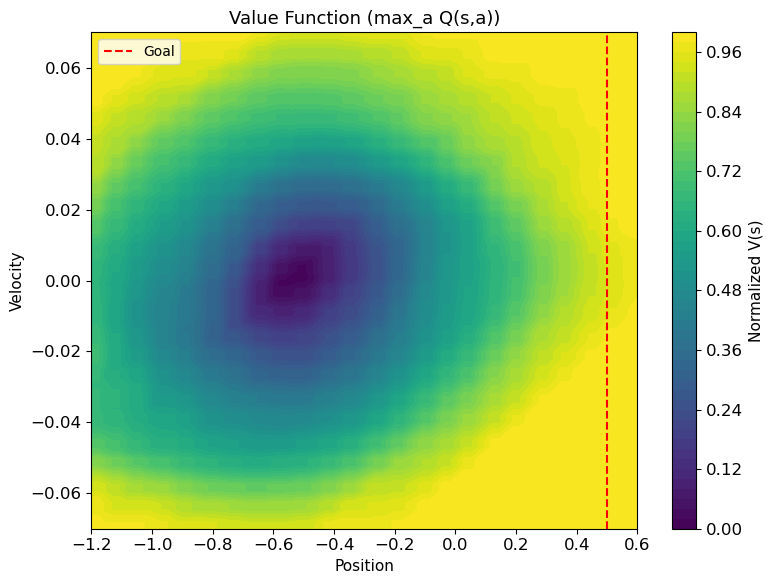

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

positions  = np.linspace(-1.2, 0.6, 80)
velocities = np.linspace(-0.07, 0.07, 80)
V = np.zeros((len(positions), len(velocities)))

for i, pos in enumerate(positions):
    for j, vel in enumerate(velocities):
        state  = np.array([pos, vel])
        active = tile_coder.get_active_tiles(state)
        q_vals = [np.sum(weights[a, active]) for a in range(weights.shape[0])]
        V[i, j] = np.max(q_vals)

print(f"V min: {V.min():.4f}, V max: {V.max():.4f}, spread: {V.max()-V.min():.4f}")

v_min, v_max = V.min(), V.max()
V = (V - v_min) / (v_max - v_min)

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(positions, velocities, V.T, levels=50, cmap="viridis")
fig.colorbar(cf, ax=ax, label="Normalized V(s)")
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title("Value Function (max_a Q(s,a))")
ax.axvline(0.5, color="red", linestyle="--", label="Goal")
ax.legend()
plt.tight_layout()
plt.show()

##  Greedy Policy Map

This shows what action the trained agent would take at every state:
- **← Left** — push left
- **· No push** — do nothing  
- **→ Right** — push right

A good policy should push right when moving right, and push left when moving left (to build momentum).

Symbolic policy (rows=position, cols=velocity):
← → → → → → · · · · → · → · → · ← · ← ← ← ← ← ← ←
← ← ← ← ← ← · · · ← ← → → → → → · · · · · → ← ← ←
· ← ← ← ← ← ← ← ← → → → → → → → → → · ← ← ← ← ← ←
← ← ← ← · ← ← ← ← ← → · → → → → → → → → ← ← ← · ←
← ← · ← · ← → ← ← · · · → → → → → → → → ← ← ← ← ←
← ← ← ← ← ← ← ← ← ← · → → → → → → → → → → ← ← ← ←
← ← ← ← · · ← ← ← ← ← ← ← · → → → → → → → → · ← ←
← ← ← · · · ← ← ← ← ← ← ← · · → → → → → → → · ← ←
← ← ← · ← ← ← ← ← ← ← ← ← → → → → → → → → → → · ←
← ← ← · ← ← ← ← ← ← ← ← ← → → → → → → → → → → ← ←
→ → · ← ← ← ← ← ← ← ← ← ← → → → → → → → → → → ← ←
→ → ← ← ← ← ← ← ← ← ← ← ← → · → · → → → → → → ← ←
→ · · ← ← ← → ← ← ← ← ← ← ← · · · → → → → → → · ←
← ← ← · · ← ← ← ← ← ← ← ← ← ← ← → → → → → → → · ←
→ → → · ← ← ← ← ← · · · ← ← ← ← → → → → → → → · ←
→ → · ← ← ← ← ← ← · · · · → · → → → → → → → → · ·
→ → → · ← · · · · · · · · · · → → → → → → → · · ·
→ → · · · · · ← ← ← ← → → → → → → → → → → → · · ·
← ← · · · · · ← ← ← ← ← ← → → → → → → → → ← · · ←
← 

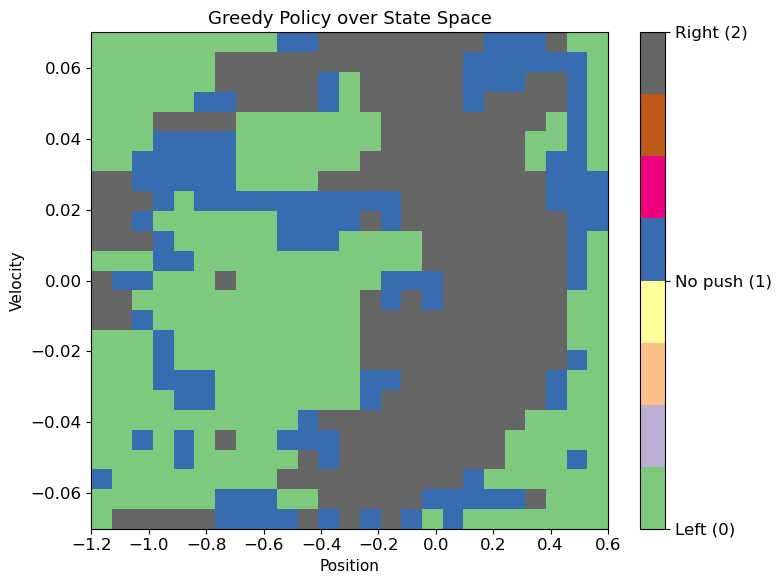

In [28]:
def compute_policy_grid(weights, tile_coder, positions, velocities):
    n_actions = weights.shape[0]
    policy = np.zeros((len(positions), len(velocities)), dtype=int)

    for i, pos in enumerate(positions):
        for j, vel in enumerate(velocities):
            state = np.array([pos, vel])
            active = tile_coder.get_active_tiles(state)

            q_vals = [np.sum(weights[a, active]) for a in range(n_actions)]
            policy[i, j] = int(np.argmax(q_vals))

    return policy


def plot_policy(weights, tile_coder, title="Greedy Policy over State Space"):
    positions  = np.linspace(-1.2, 0.6, 25)
    velocities = np.linspace(-0.07, 0.07, 25)
    policy = compute_policy_grid(weights, tile_coder, positions, velocities)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(
        policy,
        origin="lower",
        extent=[-1.2, 0.6, -0.07, 0.07],
        aspect="auto",
        interpolation="nearest",
        cmap="Accent",
    )
    cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(["Left (0)", "No push (1)", "Right (2)"])
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_title(title)
    plt.tight_layout()

    # Symbolic view
    actions_map = {0: "←", 1: "·", 2: "→"}
    print("Symbolic policy (rows=position, cols=velocity):")
    for i in range(policy.shape[0]):
        print(" ".join(actions_map[a] for a in policy[i]))

    return fig  # ← return instead of plt.show()


fig = plot_policy(weights, tile_coder)
plt.show()  # ← always call this in the cell

##  Agent Trajectories

We run the trained agent from two different starting positions and plot its path  
through the (position, velocity) space, overlaid on the value function heatmap.

A successful agent should swing back and forth, building speed until it reaches x = 0.5.

In [34]:
def run_greedy_episode(env, weights, tile_coder, start_state=None, max_steps=500):
    n_actions = weights.shape[0]

    state, _ = env.reset()

    if start_state is not None:
        env.unwrapped.state = np.array(start_state, dtype=float)
        state = np.array(start_state, dtype=float)

    positions = []
    velocities = []

    done = False
    steps = 0

    while not done and steps < max_steps:

        positions.append(state[0])
        velocities.append(state[1])

        active = tile_coder.get_active_tiles(state)
        q_vals = [np.sum(weights[a, active]) for a in range(n_actions)]
        action = int(np.argmax(q_vals))

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated
        state = next_state
        steps += 1

    return np.array(positions), np.array(velocities)


def run_greedy_episode(env, weights, tile_coder, start_state=None, max_steps=500):
    n_actions = weights.shape[0]

    state, _ = env.reset()

    if start_state is not None:
        env.unwrapped.state = np.array(start_state, dtype=float)
        state = np.array(start_state, dtype=float)

    positions = []
    velocities = []

    done = False
    steps = 0

    while not done and steps < max_steps:

        positions.append(state[0])
        velocities.append(state[1])

        active = tile_coder.get_active_tiles(state)
        q_vals = [np.sum(weights[a, active]) for a in range(n_actions)]
        action = int(np.argmax(q_vals))

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated
        state = next_state
        steps += 1

    return np.array(positions), np.array(velocities)


def plot_trajectories_on_value(weights, tile_coder, start_states,
                               title="Trajectories on Value Function"):
    positions_grid = np.linspace(-1.2, 0.6, 60)
    velocities_grid = np.linspace(-0.07, 0.07, 60)

    q_grid, pos_space, vel_space = compute_q_grid(weights, tile_coder, positions_grid, velocities_grid)
    V = np.max(q_grid, axis=2)  # ← V(s) = max_a Q(s,a), now 2D

    fig, ax = plt.subplots(figsize=(8, 6))
    cs = ax.contourf(positions_grid, velocities_grid, V.T, levels=30, cmap="viridis")
    fig.colorbar(cs, ax=ax, label="V(s)")
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_title(title)

    env_plot = gym.make("MountainCar-v0")
    for s0 in start_states:
        pos_traj, vel_traj = run_greedy_episode(
            env_plot, weights, tile_coder, start_state=s0, max_steps=500
        )
        ax.plot(pos_traj, vel_traj, linewidth=1.5, label=f"start={s0}")

    ax.axvline(0.5, color="red", linestyle="--", label="Goal")
    ax.legend()
    plt.tight_layout()
    env_plot.close()
    return fig

In [37]:
def compute_q_grid(weights, tile_coder, pos_bins=50, vel_bins=50):

    if isinstance(pos_bins, np.ndarray):
        pos_space = pos_bins
    else:
        pos_space = np.linspace(-1.2, 0.6, pos_bins)

    if isinstance(vel_bins, np.ndarray):
        vel_space = vel_bins
    else:
        vel_space = np.linspace(-0.07, 0.07, vel_bins)

    n_actions = weights.shape[0]
    q_grid = np.zeros((len(pos_space), len(vel_space), n_actions))

    for i, pos in enumerate(pos_space):
        for j, vel in enumerate(vel_space):
            state = np.array([pos, vel])
            active_tiles = tile_coder.get_active_tiles(state)  # ← fixed
            active_tiles = np.array(active_tiles).flatten().astype(int)

            for a in range(n_actions):
                q_grid[i, j, a] = np.sum(weights[a, active_tiles])

    return q_grid, pos_space, vel_space

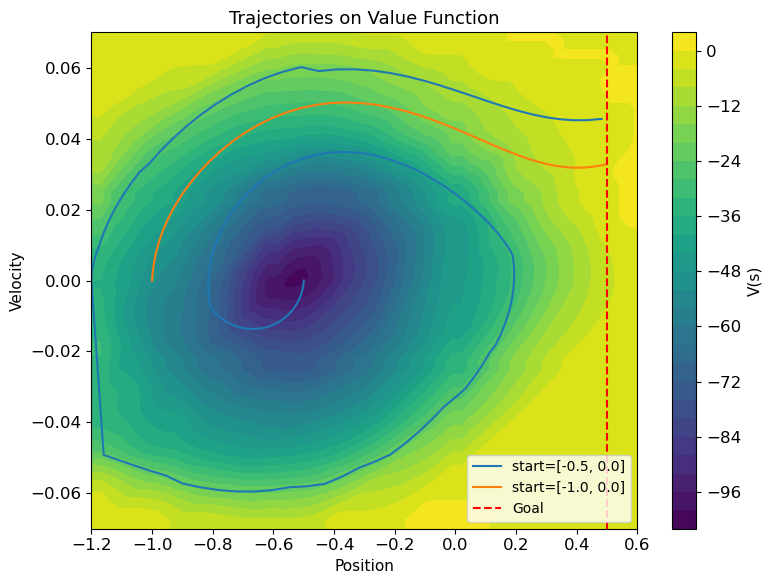

In [ ]:
fig = plot_trajectories_on_value(weights, tile_coder, start_states=[[-0.5, 0.0], [-1.0, 0.0]])
plt.show()  